# 4217 Никитин Дмитрий
## Вариант 3
Вариант 3: Восстановление пропущенных значений в датасете Human Activity Recognition:
Используем временные ряды показаний акселерометра и гироскопа для распознавания активности. Цель — интерполировать отсутствующие измерения.
Шаги работы:
1. Загрузка данных:
➢Скачать Human Activity Recognition Dataset.
➢Выбрать столбцы, связанные с ускорением (Acceleration, Gyroscope).
2. Предобработка данных:
➢Привести данные к числовому формату.
5
➢Искусственно удалить случайные точки (например, 10% измерений).
➢Добавить шум (имитировать помехи в сенсорах).
➢Разделить на обучающую и тестовую выборки.
3. Обучение модели:
➢Обучить LSTM для восстановления пропущенных значений.
➢Использовать sliding window подход для входных данных.
4. Тестирование:
➢Сравнить качество интерполяции с классическими методами (например, линейная интерполяция, сплайны).
➢Оценить качество по метрикам MSE, MAE и R²

Сначала был считан датафрейм и выявлены необходимые для изучения столбцы.

In [9]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('test.csv')
print(df.info())
print(df.columns)
for x in df.columns:
  if 'tBodyAcc-mean' in x or 'tBodyGyro-mean' in x:
    print(x)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2947 entries, 0 to 2946
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 12.7+ MB
None
Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity'],
      dtype='object', length=563)
tBodyAcc-mean()-X
tBodyAcc-mean()-Y
tBodyAcc-mean()-Z
tBodyGyro-mean()-X
tBodyGyro-mean()-Y
tBodyGyro-mean()-Z


С помощью дедуктивного метода были определены столбцы, связанные с ускорением  (Acceleration, Gyroscope). Имена столбцов:
1. tBodyAcc-mean()-X
2. tBodyAcc-mean()-Y
3. tBodyAcc-mean()-Z
4. tBodyGyro-mean()-X
5. tBodyGyro-mean()-Y
6. tBodyGyro-mean()-Z

Где первая буква t означает time. То есть имются ввиду временные характеристики.

Так как названия полей сложные, было произведено переименование в более простые названия. Также исследуемые значения были выделены в датафрейме.

In [10]:
df.rename(columns = {
    'tBodyAcc-mean()-X': 'acc_x',
    'tBodyAcc-mean()-Y': 'acc_y',
    'tBodyAcc-mean()-Z': 'acc_z',
    'tBodyGyro-mean()-X': 'gyro_x',
    'tBodyGyro-mean()-Y': 'gyro_y',
    'tBodyGyro-mean()-Z': 'gyro_z'
}, inplace=True)
df = df[['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2947 entries, 0 to 2946
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   acc_x   2947 non-null   float64
 1   acc_y   2947 non-null   float64
 2   acc_z   2947 non-null   float64
 3   gyro_x  2947 non-null   float64
 4   gyro_y  2947 non-null   float64
 5   gyro_z  2947 non-null   float64
dtypes: float64(6)
memory usage: 138.3 KB


По информации о датафрейме видно, что пропусков в нём нет. Далее были добавлены пропуски и шумы в случайном порядке, а также для профилактики конвертированы в числовые данные.

In [11]:
# Приведение данных к числовому формату
df = df.apply(pd.to_numeric, errors='raise')

print("Данные до добавления шума")
print(df)
# Добавление шума
noise = np.random.normal(0, 0.005, df.shape)
df_with_noise = df + noise
print("Данные после добавления шума:")
print(df_with_noise)
print(df_with_noise.info())

# Искусственное удаление случайных точек (10% измерений)
mask = np.random.rand(*df_with_noise.shape) < 0.1
df_with_mask = df_with_noise.mask(mask)
print("Данные после удаления 10% измерений:")
print(df_with_mask)
print(df_with_mask.info())

Данные до добавления шума
         acc_x     acc_y     acc_z    gyro_x    gyro_y    gyro_z
0     0.257178 -0.023285 -0.014654  0.119976 -0.091792  0.189629
1     0.286027 -0.013163 -0.119083 -0.001552 -0.187291  0.180705
2     0.275485 -0.026050 -0.118152 -0.048213 -0.166280  0.154174
3     0.270298 -0.032614 -0.117520 -0.056642 -0.126018  0.118337
4     0.274833 -0.027848 -0.129527 -0.059992 -0.084723  0.078659
...        ...       ...       ...       ...       ...       ...
2942  0.310155 -0.053391 -0.099109 -0.142473  0.025443  0.202862
2943  0.363385 -0.039214 -0.105915  0.062107 -0.043156  0.113594
2944  0.349966  0.030077 -0.115788 -0.123715  0.086320  0.261423
2945  0.237594  0.018467 -0.096499 -0.335912  0.099347  0.355058
2946  0.153627 -0.018437 -0.137018 -0.208229 -0.038654  0.246101

[2947 rows x 6 columns]
Данные после добавления шума:
         acc_x     acc_y     acc_z    gyro_x    gyro_y    gyro_z
0     0.255192 -0.022581 -0.010866  0.117149 -0.087845  0.191899
1     0.2

После добавления пропусков и шумов данные были разделены на обучающую и тестовую выборки в соотношении 70/30 без перемешивания.



In [12]:
# Разделение на обучающую и тестовую выборки
# df_with_mask_filled = df_with_mask.fillna(0)
df_with_mask_filled = df_with_mask.interpolate(method='linear', limit_direction='both')

train_data, test_data = train_test_split(df_with_mask_filled, test_size=0.3, shuffle=False)

print("\nОбучающая выборка:")
print(train_data.info())
print("\nТестовая выборка:")
print(test_data.info())


Обучающая выборка:
<class 'pandas.core.frame.DataFrame'>
Index: 2062 entries, 0 to 2061
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   acc_x   2062 non-null   float64
 1   acc_y   2062 non-null   float64
 2   acc_z   2062 non-null   float64
 3   gyro_x  2062 non-null   float64
 4   gyro_y  2062 non-null   float64
 5   gyro_z  2062 non-null   float64
dtypes: float64(6)
memory usage: 112.8 KB
None

Тестовая выборка:
<class 'pandas.core.frame.DataFrame'>
Index: 885 entries, 2062 to 2946
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   acc_x   885 non-null    float64
 1   acc_y   885 non-null    float64
 2   acc_z   885 non-null    float64
 3   gyro_x  885 non-null    float64
 4   gyro_y  885 non-null    float64
 5   gyro_z  885 non-null    float64
dtypes: float64(6)
memory usage: 48.4 KB
None


Далее была создана LSTM нейросеть, которая должна предсказывать следующее значение по нескольким предыдущим. Соответственно, функция create_sequences и создавёт подобные параметры. В качестве первого аргумента она возвращает список с последовательностями длиною seq_length, а в качестве второго аргумента - список с точками, которые находятся сразу после последовательности с индекса первого списка. В нейросети использовалось 3 слоя - 2 слоя LSTM и 1 Dense слой. В LSTM слое используется функция активации tanh(x) = (e^x) - (e^(-x)) / ((e^x) + (e^(-x)). Далее происходит компиляция с использованием оптимизатора adam и loss-метрики mse. А также обучение модели на тренировочных данных.

In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Функция для создания временных окон (sliding window)
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length].values)
        y.append(data.iloc[i+seq_length].values)
    return np.array(X), np.array(y)

# Создание выборок
batch_size = 32
seq_length = 128
epochs = 32
X_train, y_train = create_sequences(train_data, seq_length)
X_test, y_test = create_sequences(test_data, seq_length)

# Создание улучшенной модели LSTM
model = Sequential([
    LSTM(32, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    LSTM(16, activation='tanh'),
    Dense(X_train.shape[2])
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Обучение модели
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test))

Epoch 1/32


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - loss: 0.0143 - val_loss: 0.0134
Epoch 2/32
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - loss: 0.0106 - val_loss: 0.0133
Epoch 3/32
61/61 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - loss: 0.0114 - val_loss: 0.0134
Epoch 4/32
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 0.0106 - val_loss: 0.0134
Epoch 5/32
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.0114 - val_loss: 0.0132
Epoch 6/32
61/61 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - loss: 0.0122 - val_loss: 0.0134
Epoch 7/32
61/61 ━━━━━━━━━━━━━━━━━━━━ 13s 159ms/step - loss: 0.0118 - val_loss: 0.0133
Epoch 8/32
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.0118 - val_loss: 0.0133
Epoch 9/32
61/61 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0118 - val_loss: 0.0132
Epoch 10/32
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - loss: 0.0115 - val_loss: 0.0132
Epoch 11/32
61/61 ━━━━━━━━━━━━━━━━━━━━ 11s 132ms/step - loss: 0.0111 - val_loss: 0.0132
Epoch 12/32
61/61 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - loss

После успешного обучения была проведена оценка модели.

In [14]:
# Оценка модели
y_pred = model.predict(X_test)
print(y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}, MAE: {mae}, R²: {r2}")

# Сравнение с линейной интерполяцией
y_interp = test_data.interpolate(method='linear', limit_direction='both').values[seq_length:]
interp_mse = mean_squared_error(y_test, y_interp)
interp_mae = mean_absolute_error(y_test, y_interp)
interp_r2 = r2_score(y_test, y_interp)

print(f"Linear Interpolation - MSE: {interp_mse}, MAE: {interp_mae}, R²: {interp_r2}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step
[[ 0.26734856 -0.02073289 -0.10752192 -0.06234688 -0.00877551  0.00247332]
 [ 0.256255   -0.02863559 -0.12073585 -0.33408588  0.05227068  0.24217442]
 [ 0.23624262 -0.02174587 -0.12932849 -0.21443017  0.03642082  0.22555104]
 ...
 [ 0.19715019 -0.01341729 -0.1641633  -0.0704129  -0.01035109  0.04330307]
 [ 0.19071655 -0.00332446 -0.16957152 -0.1731587   0.00904159  0.1453949 ]
 [ 0.1889343  -0.00148023 -0.17356414 -0.1446188  -0.01321433  0.19991487]]
MSE: 0.009878084939311667, MAE: 0.04821342885872065, R²: 0.1045365210751133
Linear Interpolation - MSE: 0.0, MAE: 0.0, R²: 1.0


Выяснилось, что данная LSTM модель достаточно плохо справляется с задачей предсказания следующего числа в последовательности. Каждая из метрик подтверждает мои слова. Оценка применимости модели - неудовлетворительно.

В отличие от LSTM линейная интерполяция отлично справилась с задачей, что позволяет сказать, что в этом случае предпочтительнее использовать линейную интерполяцию, а не эту модель LSTM.

Далее показаны требуемые графики.

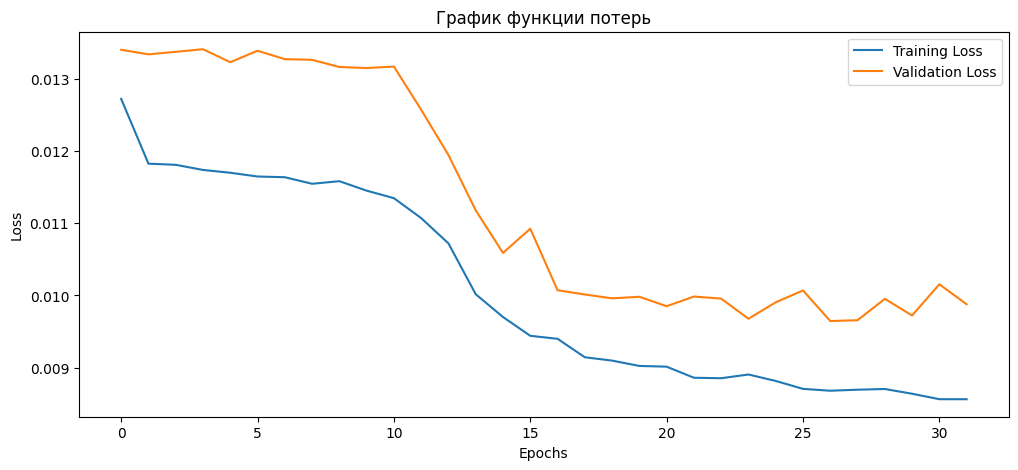

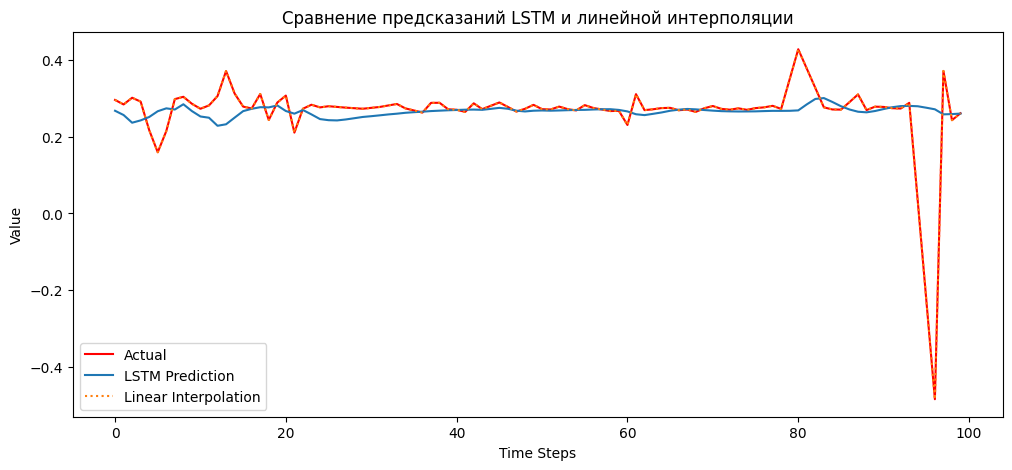

In [15]:
# Визуализация обучения
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('График функции потерь')
plt.savefig('result1.png')
plt.show()


# Визуализация предсказанных и истинных значений
plt.figure(figsize=(12, 5))
plt.plot(y_test[:100, 0], label='Actual', color='red')
plt.plot(y_pred[:100, 0], label='LSTM Prediction')
plt.plot(y_interp[:100, 0], label='Linear Interpolation', linestyle='dotted')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.title('Сравнение предсказаний LSTM и линейной интерполяции')
plt.savefig('result2.png')
plt.show()


График функции потерь говорит о том, что модель не переобучена, так как не наблюдается роста потерь.

Однако график предсказаний LSTM и линейной интерполяции говорит о том, что модель бьёт невпопад постоянно только отдалённо напоминая исходные данные. После 7 часов непрерывного подбора можно сделать вывод только о том, что либо модель неправильно сконструирована, либо данные неправильно интерпретированы, либо данные неправильно обработаны.